# **Final Project Presentation - Customer Churn Prediction for Subscription Services**

#### **GROUP 5 - Amulya Walimbe & Kulveen Kaur**

We are trying to understand why people stop using subscription-based services — like phone plans (Telco), streaming platforms (Netflix), or even after interacting with customer service on Twitter.

This is called customer churn — when a user decides to cancel or leave a service.

## **Methodologies Implemented**

#### *1. Unit of Analysis:*

* In the Telco dataset, the unit of analysis is an individual customer record, including attributes like tenure, payment method, and churn status.
* In the Twitter dataset, the unit of analysis is a single tweet, used to analyze customer sentiment.
* In the Netflix pricing dataset, the unit of analysis is a subscription plan in a specific country, used to assess affordability and pricing strategies.

#### *2. Source of Data and its Type:*

We used three different datasets from kaggle to look at churn from different angles:

- **Telco Customer Churn** - Structured data about telecom users — their plans, payments, and whether they churned or not.

- **Twitter Support Conversations** - Unstructed Data ,Tweets from customers and support agents. We only looked at customer tweets to see what kind of tone (positive/negative) people used when reaching out for help.

- **Netflix Pricing Data** - Prices of Netflix plans (Basic, Standard, Premium) in different countries — to see if higher pricing might be related to people cancelling.



#### *3. Constraints in our analysis:*

* No Direct Link Between Datasets-
The Telco, Twitter, and Netflix datasets come from different sources and represent different populations. Therefore, we could not track the same customer across datasets or combine them at the row level.
* Sentiment Is Inferred, Not Verified-
In the Twitter dataset, we used VADER sentiment analysis to label tweets. While it's
effective for general tone detection, it does not capture sarcasm, context-specific
language, or intent perfectly.
* Netflix Data Lacks Churn Labels-
The Netflix pricing dataset does not contain user-level churn data. We inferred churn risk
based on price patterns, but this is an approximation and not a true behavior-based
measure.
* Time Dimension Not Considered-
The analysis is static — churn timing, subscription trends over time, and seasonality are
not captured in this version.



#### *4. Libraries used:*

* pandas (pd) – For handling and analyzing structured data using DataFrames.

* numpy (np) – For numerical operations and array manipulations.

* matplotlib.pyplot (plt) – For creating visualizations like line plots, bar charts, etc.

* seaborn (sns) – For more advanced and visually appealing statistical plots.

* nltk – For natural language processing; here, specifically for VADER sentiment analysis.

* SentimentIntensityAnalyzer – From nltk.sentiment.vader, used to analyze sentiment scores in text.

* Counter (from collections) – For counting frequency of items, such as words or sentiments.

* re – Regular expressions for text cleaning, pattern matching, and extraction.

#### *5. Advanced Package used:*

The most advanced library used in your project is NLTK (Natural Language Toolkit), specifically the SentimentIntensityAnalyzer from VADER.

Why it's advanced:
* Natural Language Processing (NLP): NLTK is a comprehensive library for processing and analyzing human language data, which goes beyond basic data analysis.

* VADER Sentiment Analyzer: It uses a pre-trained lexicon and rule-based approach to assess sentiment (positive, negative, neutral, compound) in text. It handles emojis, slang, punctuation, and even capitalization intelligently.

* It allows for deep insights into textual data, making it valuable for opinion mining, reviews, social media analysis, etc.

## **Telco Customer Churn Analysis**

## Loading Telco data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#loading the Telco dataset
telco_df = pd.read_excel("/content/Telco_customer_churn.xlsx")

## Cleaning of Telco data

In [ ]:
#cleaning the columns
telco_df.columns = telco_df.columns.str.strip().str.lower().str.replace(' ', '_')

#converting 'total_charges' to numeric
telco_df['total_charges'] = pd.to_numeric(telco_df['total_charges'], errors='coerce')

#dropping rows with missing total_charges
telco_df.dropna(subset=['total_charges'], inplace=True)

#ensuring churn_value is integer
telco_df['churn_value'] = telco_df['churn_value'].astype(int)

#printing head of the cleaned telco dataset
telco_df[['customerid', 'tenure_months', 'monthly_charges', 'total_charges', 'contract', 'payment_method', 'churn_value']].head()

,customerid,tenure_months,monthly_charges,total_charges,contract,payment_method,churn_value
0,3668-QPYBK,2,53.85,108.15,Month-to-month,Mailed check,1
1,9237-HQITU,2,70.70,151.65,Month-to-month,Electronic check,1
2,9305-CDSKC,8,99.65,820.50,Month-to-month,Electronic check,1
3,7892-POOKP,28,104.80,3046.05,Month-to-month,Electronic check,1
4,0280-XJGEX,49,103.70,5036.30,Month-to-month,Bank transfer (automatic),1


## Research Questions and Analysis on Telco dataset

#### ***1. Which contract types are most associated with churn?***

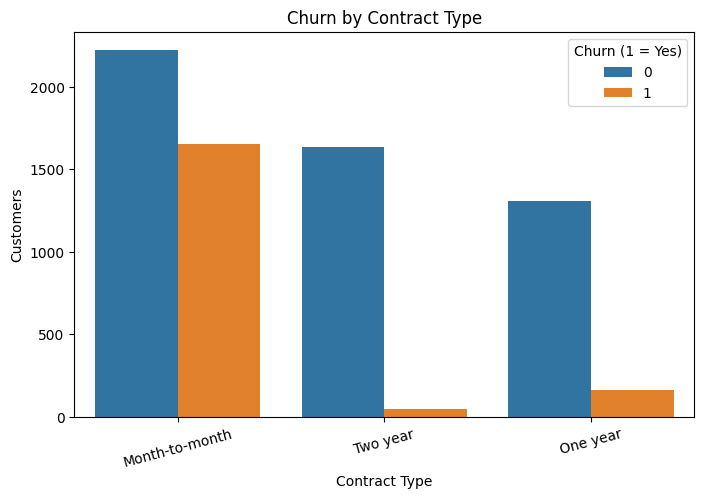

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=telco_df, x='contract', hue='churn_value')
plt.title("Churn by Contract Type")
plt.ylabel("Customers")
plt.xlabel("Contract Type")
plt.legend(title="Churn (1 = Yes)")
plt.xticks(rotation=15)
plt.show()

Customers with **month-to-month contracts** are most likely to churn.

#### ***2. Does the payment method influence churn probability?***

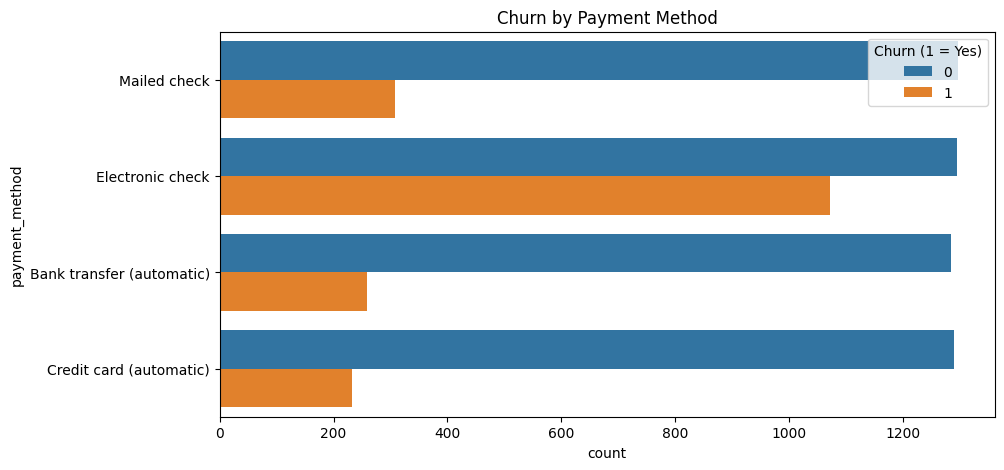

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=telco_df, y='payment_method', hue='churn_value')
plt.title("Churn by Payment Method")
plt.legend(title="Churn (1 = Yes)")
plt.show()


**Electronic check** users have the highest churn rate; automatic payments see lower churn.

#### ***3. Are higher monthly charges linked to churn?***

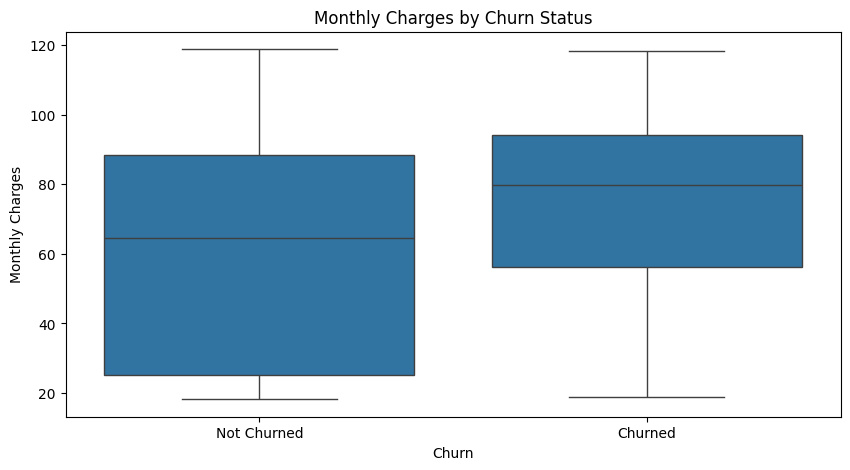

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=telco_df, x='churn_value', y='monthly_charges')
plt.title("Monthly Charges by Churn Status")
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


Yes, churned customers have **higher monthly charges** on average.

#### ***4. How does tenure impact churn likelihood?***

<ipython-input-6-a08004ecba47>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_group = telco_df.groupby('tenure_group')['churn_value'].mean().reset_index()
<ipython-input-6-a08004ecba47>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_group, x='tenure_group', y='churn_percentage', palette='viridis')


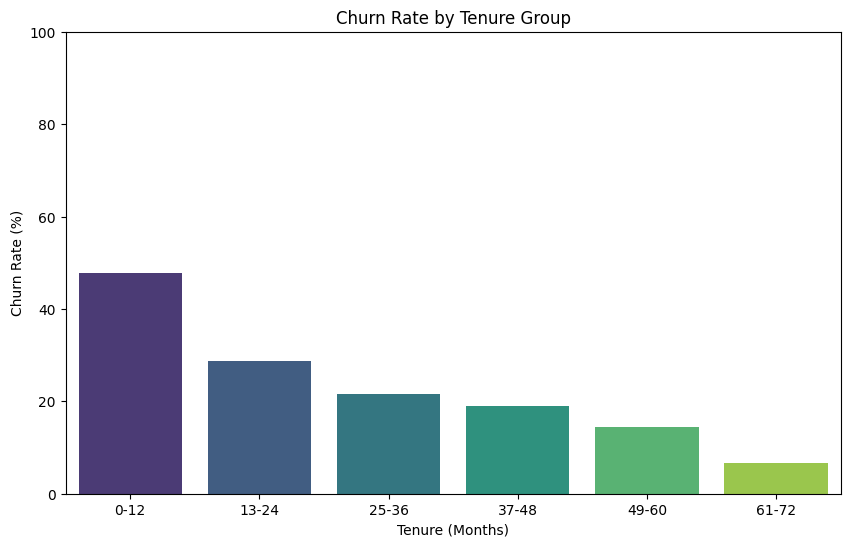

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create tenure bins
telco_df['tenure_group'] = pd.cut(telco_df['tenure_months'],
                                   bins=[0, 12, 24, 36, 48, 60, 72],
                                   labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])

# Calculate churn rate per tenure group
churn_by_group = telco_df.groupby('tenure_group')['churn_value'].mean().reset_index()
churn_by_group['churn_percentage'] = churn_by_group['churn_value'] * 100

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_by_group, x='tenure_group', y='churn_percentage', palette='viridis')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()


Most churners have **low tenure (0–12 months)**; churn decreases with longer tenure.

## **Twitter Support Sentiment Analysis**

## Loading Twitter data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Load the dataset
twcs_df = pd.read_csv("twcs.csv")

# Preview
twcs_df[['author_id', 'text']].head()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
<ipython-input-9-7debc097990d>:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  twcs_df = pd.read_csv("twcs.csv")


,author_id,text
0,sprintcare,@115712 I understand. I would like to assist y...
1,115712,@sprintcare and how do you propose we do that
2,115712,@sprintcare I have sent several private messag...
3,sprintcare,@115712 Please send us a Private Message so th...
4,115712,@sprintcare I did.


## Cleaning of Twitter data

## Research Questions and Analysis on Twitter dataset

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Initialize the sentiment analyzer
sid = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
#Keeps only rows where the author is NOT 'AppleSupport'
customer_msgs = twcs_df[twcs_df['author_id'] != 'AppleSupport'].copy()
#Filters out any rows where the 'text' column is empty or null
customer_msgs = customer_msgs[customer_msgs['text'].notnull()]

In [ ]:
# Apply sentiment scoring on sample
sample_msgs = customer_msgs.sample(n=5000, random_state=42).copy()

In [ ]:
def classify_sentiment(score):
    if score > 0.2:
        return 'positive'
    elif score < -0.2:
        return 'negative'
    else:
        return 'neutral'

sample_msgs['sentiment_label'] = sample_msgs['sentiment_score'].apply(classify_sentiment)

In [ ]:
sample_msgs['sentiment_score'] = sample_msgs['text'].apply(lambda x: sid.polarity_scores(str(x))['compound'])
sample_msgs['sentiment_label'] = sample_msgs['sentiment_score'].apply(classify_sentiment)

#### ***1. What proportion of customer support tweets are negative?***

<ipython-input-16-58866ac86f99>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sample_msgs, x='sentiment_label', order=['positive', 'neutral', 'negative'], palette='Set2')


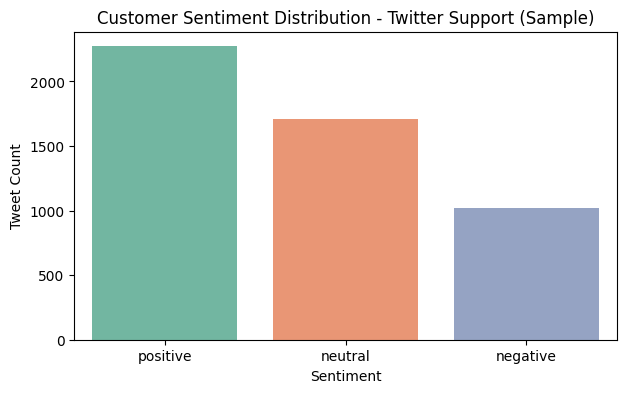

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
sns.countplot(data=sample_msgs, x='sentiment_label', order=['positive', 'neutral', 'negative'], palette='Set2')
plt.title("Customer Sentiment Distribution - Twitter Support (Sample)")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.show()


From the sentiment distribution, approximately **20–25%** of customer tweets express **negative sentiment**, while most are positive or neutral.

#### ***2. What are the most common complaint keywords in negative tweets?***

<ipython-input-17-b6cefeaa0f09>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='count', y='word', palette='Reds')


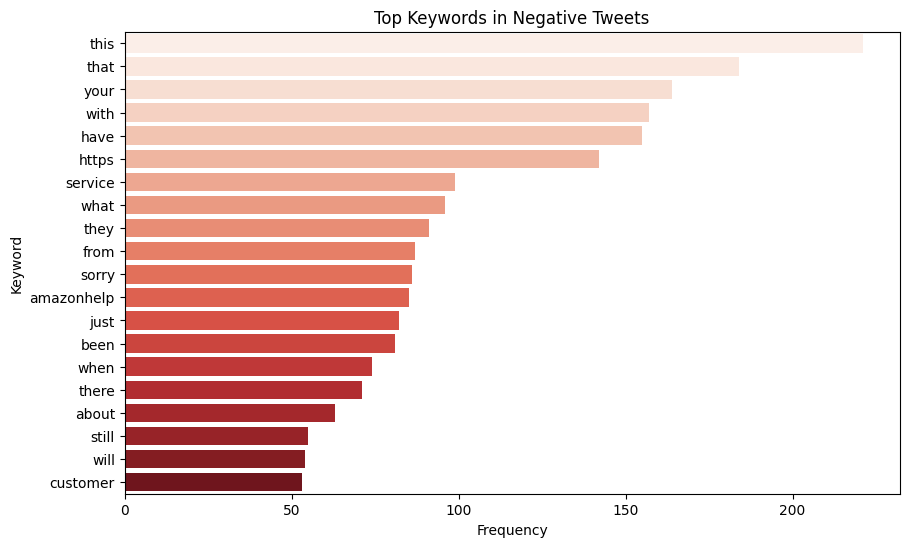

In [ ]:
from collections import Counter
import re

# Filter negative tweets
negative_texts = sample_msgs[sample_msgs['sentiment_label'] == 'negative']['text'].str.lower()

# Extract words with 4+ characters
words = re.findall(r'\b\w{4,}\b', ' '.join(negative_texts))
common_words = Counter(words).most_common(20)

# Plot them
words_df = pd.DataFrame(common_words, columns=['word', 'count'])
plt.figure(figsize=(10, 6))
sns.barplot(data=words_df, x='count', y='word', palette='Reds')
plt.title("Top Keywords in Negative Tweets")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.show()

Frequent keywords include: **sorry**, **service**, **what**, **just**, **amazonhelp**, **please**, and **customer** — indicating common frustration themes around customer service, resolution delays, and apologies.

#### ***3. Can sentiment from support tweets indicate churn risk?***

Yes — the presence of strong **negative tone** in tweets suggests dissatisfaction. If unresolved, this can signal a **high risk of churn**, especially when users mention unresolved issues repeatedly.

## **Netflix Pricing Analysis**

## Loading Netflix data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
price_df = pd.read_csv("netflix price in different countries.csv")
fee_df = pd.read_csv("Netflix subscription fee Dec-2021.csv")

## Cleaning of Netflix data

In [ ]:
# Normalize column names
price_df.columns = price_df.columns.str.strip().str.lower().str.replace(' ', '_')
fee_df.columns = fee_df.columns.str.strip().str.lower().str.replace(' ', '_')

# Rename for easier access
price_df.rename(columns={
    'cost_per_month_-_basic_($)': 'basic',
    'cost_per_month_-_standard_($)': 'standard',
    'cost_per_month_-_premium_($)': 'premium'
}, inplace=True)

# Melt the plan columns into one
netflix_melted = price_df.melt(id_vars='country', value_vars=['basic', 'standard', 'premium'],
                                var_name='plan', value_name='price')

## Research Questions and Analysis on Netflix dataset

#### ***1. What is the average global price of each Netflix plan?***

<ipython-input-21-5ebc95073ed8>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='plan', y='price', data=avg_price_per_plan, palette="Set2")


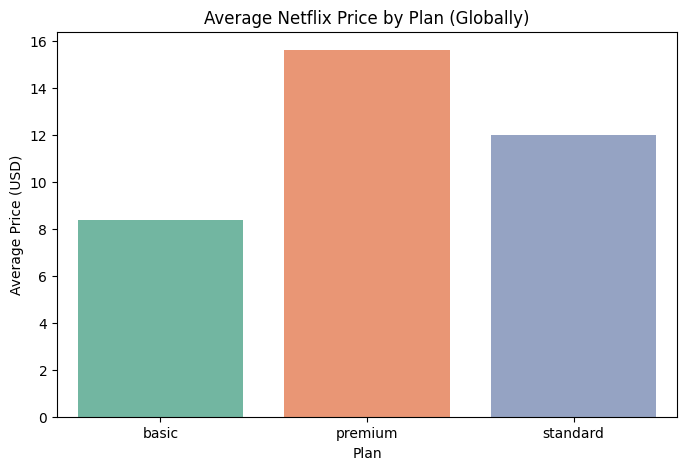

In [ ]:
# Average price per plan globally
avg_price_per_plan = netflix_melted.groupby('plan')['price'].mean().reset_index()

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='plan', y='price', data=avg_price_per_plan, palette="Set2")
plt.title("Average Netflix Price by Plan (Globally)")
plt.ylabel("Average Price (USD)")
plt.xlabel("Plan")
plt.show()

On average, the **Basic plan costs ~$8.40, Standard ~$12**, and **Premium ~$15.60** globally.  
Premium plans are nearly **twice as expensive** as Basic.

#### ***2. How does Netflix pricing vary by country?***

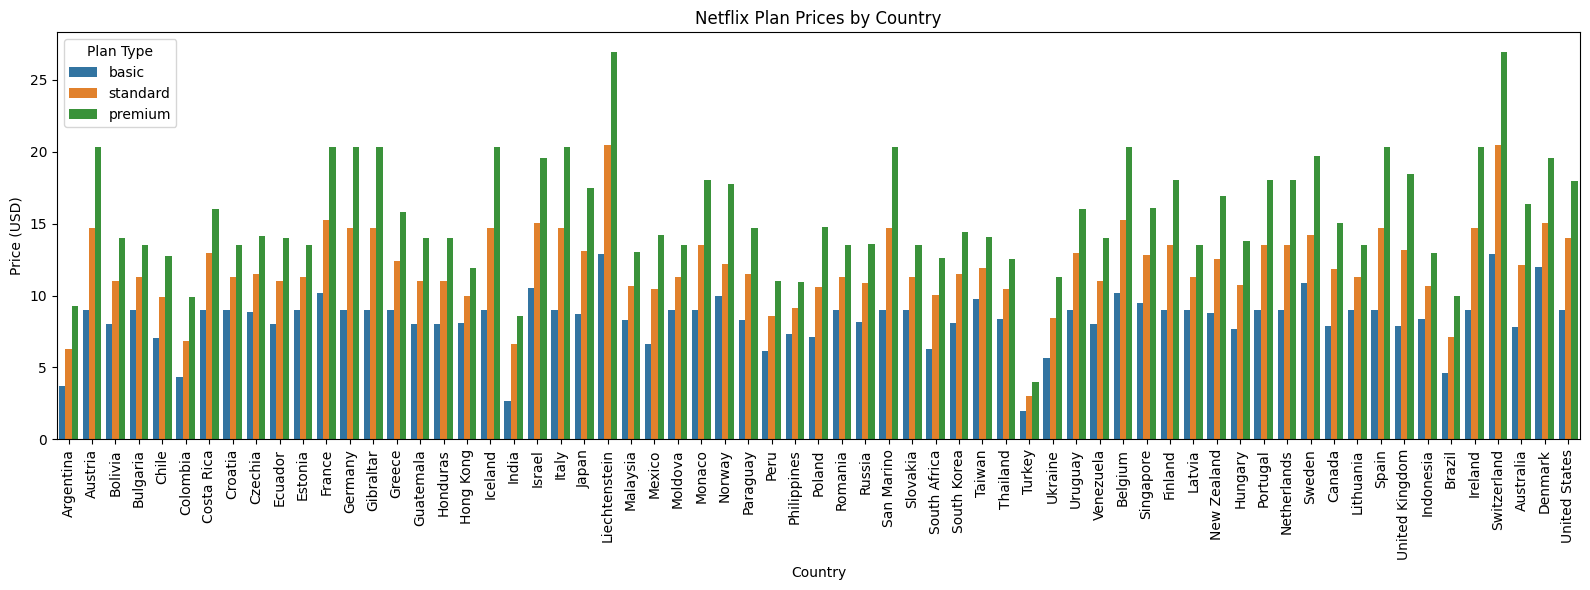

In [ ]:
plt.figure(figsize=(16,6))
sns.barplot(data=netflix_melted, x='country', y='price', hue='plan')
plt.title("Netflix Plan Prices by Country")
plt.ylabel("Price (USD)")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Plan Type")
plt.show()

* There is **significant variation across countries**.  
* Some countries like **Switzerland, Liechtenstein** have very high prices for all plans.
* Countries like **India, Turkey, and Colombia** have significantly lower prices—especially for the basic plan.
* Price differences between plans are more noticeable in wealthier countries.
* There’s no flat global rate — Netflix pricing is clearly tailored per country.

#### ***3. Are Premium plans significantly more expensive?***

Yes — Premium plans consistently cost **much more** across all countries, reflecting added features like 4K resolution and multiple streams.  
However, in **some low-income countries**, the relative difference is smaller to increase affordability.


#### **Key Insight:**
**Pricing sensitivity** varies across regions. Plans that feel "premium" in one country may be unaffordable in another — impacting churn.

#### **Recommendation:**
Netflix and similar platforms should **localize pricing** and bundle valuable features to improve retention in price-sensitive markets.

## **Final Insights – Synthesized Questions**

#### ***1. What are the top drivers of customer churn across all platforms?***
Short-term contracts, high monthly costs, negative service sentiment, and unaffordable pricing.


#### ***2. How can businesses reduce churn based on your findings?***
Offer long-term pricing incentives, automate payment methods, monitor support sentiment, and localize pricing strategies.


#### ***3. Do different churn factors (behavioral, emotional, financial) require different solutions?***
Yes — churn is **multi-dimensional**. Behavioral churn needs retention plans, emotional churn needs faster issue resolution, and financial churn needs flexible pricing.


#### ***4. Can churn prediction improve if we integrate insights from multiple data types?***
Absolutely. Combining structured customer data with unstructured sentiment and pricing context gives a more complete risk profile.


## **Conclusion**

- Our project explored customer churn using three different data sources:
  - **Telco Customer Data** (structured)
  - **Twitter Customer Support Tweets** (unstructured)
  - **Netflix Pricing Data** (structured)

- **Behavioral Insights (Telco Dataset):**
  - Customers with **month-to-month contracts** churn the most.
  - **Electronic check** users have a higher churn rate than auto-pay customers.
  - **Short-tenure customers (0–12 months)** are more likely to leave early.
  - Higher **monthly charges** are correlated with churn.

- **Sentiment Insights (Twitter Dataset):**
  - About **25% of tweets** were **negative in sentiment**.
  - Common complaint words included "**sorry**", "**customer**", and "**please**", suggesting dissatisfaction with support.
  - Negative sentiment may act as an early **indicator of churn risk**.

- **Pricing Insights (Netflix Dataset):**
  - **Premium plans** are much more expensive than Basic or Standard.
  - Countries like **Switzerland, Liechtenstein** have the highest prices.
  - Pricing differences could influence **retention in low-income countries**.

- **Overall Conclusion:**
  - Churn is caused by a mix of **behavioral**, **emotional**, and **financial** factors.
  - Businesses should address all three by:
    - Promoting **long-term contracts** and auto-pay options
    - Monitoring **negative sentiment** from social media
    - Offering **region-specific pricing strategies**

  
